# Итоговая контрольная работа по предмету "Временные Ряды"

---

Датасет: Daily Climate time series data

Ссылка на Kaggle:
https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

---

## Исследование и анализ исходных данных (EDA)

### Описание датасета
В качестве основы для выполнения итоговой контрольной работы используется набор данных **Daily Delhi Climate Dataset**, содержащий ежедневные метеорологические наблюдения в городе Дели (Индия) за период с 1 января 2013 года по 24 апреля 2017 года. Данные собраны с помощью API Weather Underground.

**Целевая задача:** Решение задачи регрессии — прогнозирование средней суточной температуры (`meantemp`) на основе исторических данных и сопутствующих метеорологических признаков.

---

### Размер выборки и структура данных
Датасет разделен на две части:
* **Тренировочная выборка (`DailyDelhiClimateTrain.csv`):** 1462 записи (период с 01.01.2013 по 01.01.2017).
* **Тестовая выборка (`DailyDelhiClimateTest.csv`):** 114 записей (период с 01.01.2017 по 24.04.2017).

Временной шаг наблюдений — **1 день**. Пропуски в данных отсутствуют.

---

### Описание признаков (Мультивариативный ряд)

| Название признака | Тип данных | Описание | Роль в модели |
| :--- | :--- | :--- | :--- |
| `date` | DateTime | Дата регистрации параметров (ГГГГ-ММ-ДД) | Индекс ряда |
| **`meantemp`** | Float | Средняя сутая температура в градусах Цельсия (°C) | **Целевой признак ($y$)** |
| `humidity` | Float | Средняя влажность воздуха (%) | Фактор ($X$) |
| `wind_speed` | Float | Средняя скорость ветра (км/ч) | Фактор ($X$) |
| `meanpressure` | Float | Среднее атмосферное давление (атм/мм рт. ст.) | Фактор ($X$) |

---

### Анализ стационарности, тренда и сезонности

1. **Сезонность и тренд:** Визуальный анализ графиков целевого признака `meantemp` показывает ярко выраженную **годовую (циклическую) сезонность** с пиками температуры в районе мая-июня и спадами в январе-декабре. Глобальный многолетний тренд практически отсутствует (температурные колебания колеблются в стабильном историческом коридоре от ~6°C до ~38°C).

2. **Стационарность ряда:**
   Поскольку математическое ожидание и дисперсия ряда периодически изменяются в зависимости от времени года (выраженная сезонная компонента), исходный временной ряд является **нестационарным**. 
   *Для корректного обучения классических моделей и извлечения признаков в пайплайне будут применены методы лагов (Lag features) и скользящих окон (Rolling Statistics), которые частично компенсируют нестационарность за счет учета локального контекста.*

---

### 0. Установка зависимостей

In [6]:

%pip install numpy pandas matplotlib seaborn scikit-learn statsmodels torch

Note: you may need to restart the kernel to use updated packages.


### 1. Импорт библиотек и настройка окружения

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

### 2. Загрузка данных и базовый EDA (Exploratory Data Analysis)

Размер выборки: (1462, 4)

Базовое описание признаков:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1008.249852
std,7.348103,16.769652,4.561602,7.437428
min,6.000000,13.428571,0.000000,991.375000
25%,18.857143,50.375000,3.475000,1001.625000
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.875000
max,38.714286,100.000000,42.220000,1023.000000


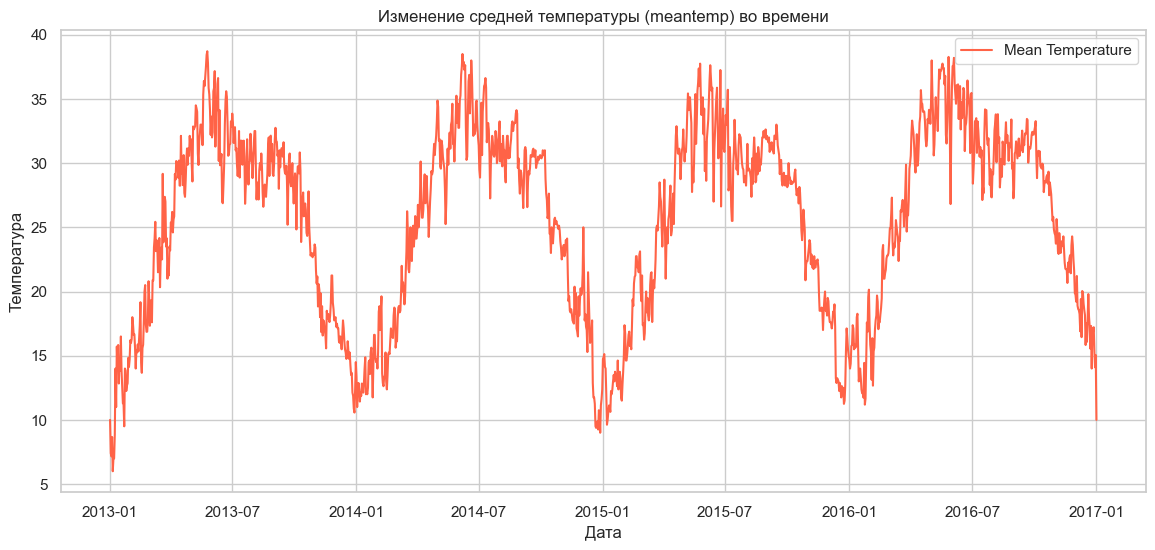

Результаты теста Дики-Фуллера:
ADF Statistic: -2.0211
p-value: 0.2774
Ряд нестационарен (не можем отвергнуть нулевую гипотезу).


In [8]:
df = pd.read_csv('DailyDelhiClimateTrain.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df['meanpressure'] = df['meanpressure'].where(df['meanpressure'].between(950, 1050))
df['meanpressure'] = df['meanpressure'].interpolate(method='linear')
df['meanpressure'] = df['meanpressure'].bfill().ffill()

print(f"Размер выборки: {df.shape}")
print("\nБазовое описание признаков:")
display(df.describe())

# Визуализация целевого признака
plt.plot(df.index, df['meantemp'], label='Mean Temperature', color='tomato')
plt.title('Изменение средней температуры (meantemp) во времени')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.legend()
plt.show()

# Тест Дики-Фуллера на стационарность
print("Результаты теста Дики-Фуллера:")
result = adfuller(df['meantemp'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Ряд стационарен (отвергаем нулевую гипотезу).")
else:
    print("Ряд нестационарен (не можем отвергнуть нулевую гипотезу).")

### 3. Декомпозиция ряда

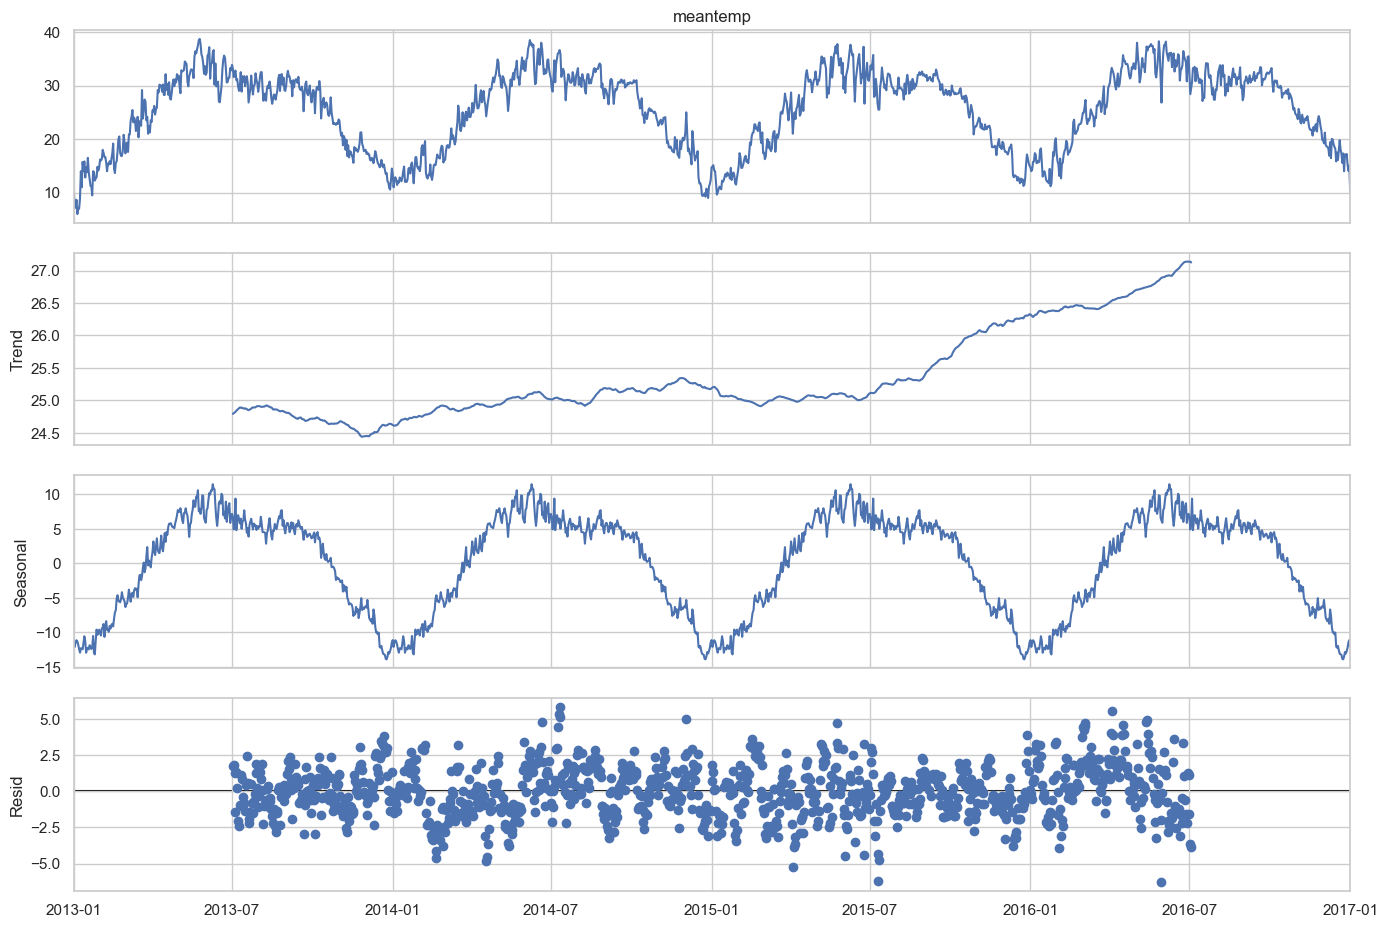

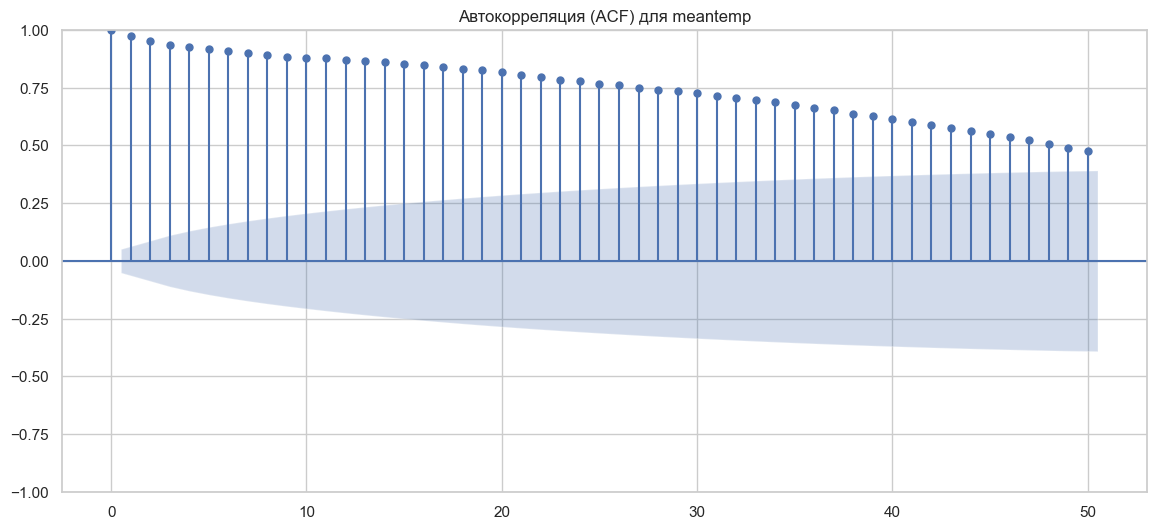

In [9]:
# Декомпозиция ряда (период = 365 дней для годовой сезонности)
decomposition = seasonal_decompose(df['meantemp'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

# График автокорреляции (ACF)
plot_acf(df['meantemp'], lags=50, title='Автокорреляция (ACF) для meantemp')
plt.show()

тренд - явно возрастающий, что указывает на общее потепление в рассматриваемый период, график обкусан по краям и короче исходного ряда, это происходит из-за центрирования окна, в результате которого мы теряем по полгода данных в начале и конце временного ряда

сезонность - идеально правильная повторяющаяся синусоида с амплитудой от -12 до 10 градусов, период сезонности равен одному году, значения колеблются относительно нуля, что подтверждает корректность использования аддитивной модели

График ACF убывает крайне медленно, что является классическим признаком нестационарности исходного временного ряда. Высокая автокорреляция на больших лагах подтверждает наличие сильного тренда. Значения температуры очень сильно зависят от своих предыдущих состояний, т.е. температура сегодня очень сильно скоррелирована с температурой вчера, позавчера и тд.


### 4. Извлечение признаков (Feature Extraction)

In [10]:
# 1. Календарные признаки (Time features)
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear

# 2. Lag features (значения за предыдущие дни)
df['lag_1'] = df['meantemp'].shift(1)
df['lag_2'] = df['meantemp'].shift(2)
df['lag_7'] = df['meantemp'].shift(7)

# 3. Rolling statistics (скользящие средние)
df['rolling_mean_7'] = df['meantemp'].shift(1).rolling(window=7).mean()
df['rolling_std_7'] = df['meantemp'].shift(1).rolling(window=7).std()

df.dropna(inplace=True)

print(f"Размер выборки после извлечения признаков: {df.shape}")
display(df.head(3))

Размер выборки после извлечения признаков: (1455, 11)


,meantemp,humidity,wind_speed,meanpressure,month,day_of_year,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,
2013-01-08,8.857143,63.714286,7.142857,1018.714286,1,8,7.000000,7.000000,10.000000,7.604762,1.316903
2013-01-09,14.000000,51.250000,12.500000,1017.000000,1,9,8.857143,7.000000,7.400000,7.441497,1.004166
2013-01-10,11.000000,62.000000,7.400000,1015.666667,1,10,14.000000,8.857143,7.166667,8.384354,2.672062


Признаки в датасете:
date (индекс) — дата наблюдения (формат YYYY-MM-DD).

meantemp (целевой признак) — средняя суточная температура в градусах Цельсия.

humidity — средняя влажность воздуха за сутки (в процентах).

wind_speed — средняя скорость ветра (в км/ч).

meanpressure — среднее атмосферное давление.

lag 1 — значение температуры ровно 1 день назад (вчера).

lag 2 — значение температуры 2 дня назад (позавчера).

lag 3 — значение температуры 3 дня назад (три дня назад).

rolling mean 7 — это среднее значение температуры за последние 7 дней

rolling std (Rolling Standard Deviation) — это стандартное отклонение, посчитанное по скользящему окну



### 5. Предобработка и формирование выборок

In [11]:
X = df.drop(['meantemp'], axis=1)
y = df['meantemp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка: {X_test_scaled.shape}")

Обучающая выборка: (1164, 10)
Тестовая выборка: (291, 10)


### 6: Random Forest Regressor

In [12]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Metrics for Random Forest:")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

Metrics for Random Forest:
MAE: 1.1710
RMSE: 1.4753


### 7: Подготовка тензоров для CNN и GRU

In [13]:
# Формат: [samples, time_steps, features]
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1) 
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

num_features = X_train_scaled.shape[1]
print(f"Размерность тензора признаков: {X_train_t.shape}")

Размерность тензора признаков: torch.Size([1164, 1, 10])


### 8: Обучение CNN1D

In [ ]:
class CNN1D_Model(nn.Module):
    def __init__(self, input_dim):
        super(CNN1D_Model, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(16 * input_dim, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn_model = CNN1D_Model(num_features)
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.01)

epochs = 50
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

cnn_model.eval()
with torch.no_grad():
    cnn_preds = cnn_model(X_test_t).numpy()

cnn_mae = mean_absolute_error(y_test, cnn_preds)
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_preds))

print("Metrics for CNN1D:")
print(f"MAE: {cnn_mae:.4f}")
print(f"RMSE: {cnn_rmse:.4f}")

Metrics for CNN1D:
MAE: 1.3965
RMSE: 1.7256


### 9. Обучение GRU

In [ ]:
class GRU_Model(nn.Module):
    def __init__(self, input_dim):
        super(GRU_Model, self).__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRU_Model(num_features)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.01)

for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer_gru.zero_grad()
        outputs = gru_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_gru.step()

gru_model.eval()
with torch.no_grad():
    gru_preds = gru_model(X_test_t).numpy()

gru_mae = mean_absolute_error(y_test, gru_preds)
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_preds))

print("Metrics for GRU:")
print(f"MAE: {gru_mae:.4f}")
print(f"RMSE: {gru_rmse:.4f}")

Metrics for GRU:
MAE: 1.3218
RMSE: 1.6394


### 10: Сводная таблица результатов

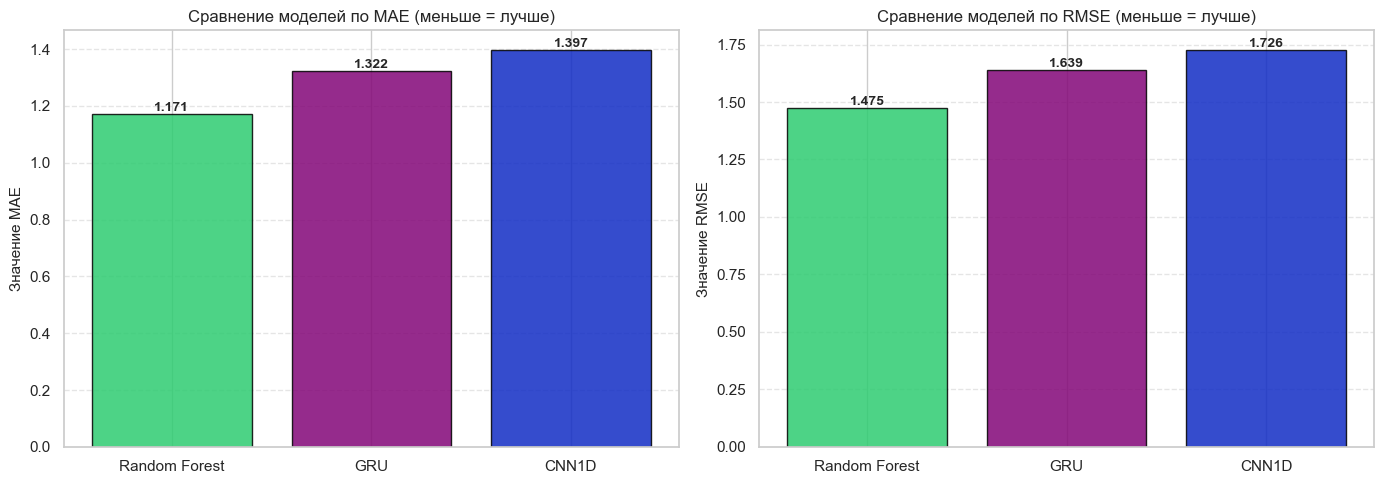

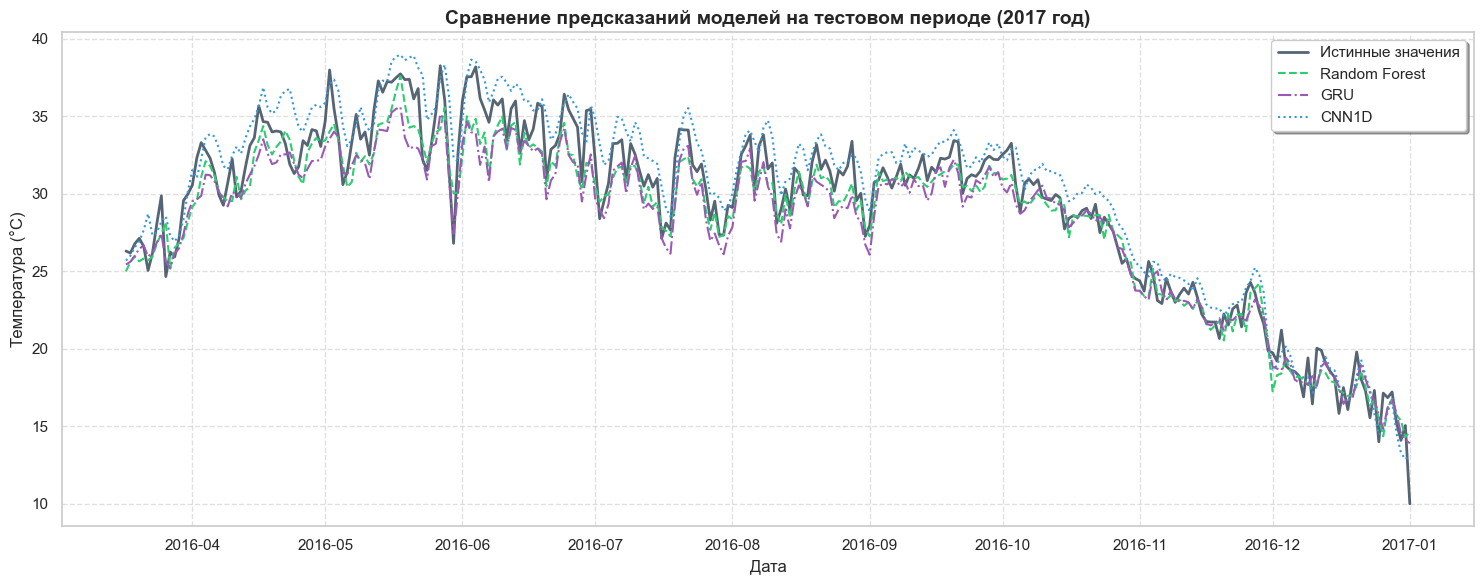

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_sorted = results.sort_values(by='MAE')

colors = ['#2ecc71', "#830678", "#112CC5"]

axes[0].bar(results_sorted['Модель'], results_sorted['MAE'], color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Сравнение моделей по MAE (меньше = лучше)', fontsize=12)
axes[0].set_ylabel('Значение MAE', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.3f}', 
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].bar(results_sorted['Модель'], results_sorted['RMSE'], color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Сравнение моделей по RMSE (меньше = лучше)', fontsize=12)
axes[1].set_ylabel('Значение RMSE', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.3f}', 
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 6))

plt.plot(y_test.index, y_test.values, label='Истинные значения', color='#2c3e50', linewidth=2, alpha=0.8, zorder=1)

plt.plot(y_test.index, rf_preds, label='Random Forest', color='#2ecc71', linestyle='--', linewidth=1.5, zorder=3)
plt.plot(y_test.index, gru_preds, label='GRU', color='#9b59b6', linestyle='-.', linewidth=1.5, zorder=4)
plt.plot(y_test.index, cnn_preds, label='CNN1D', color='#3498db', linestyle=':', linewidth=1.5, zorder=2)

plt.title('Сравнение предсказаний моделей на тестовом периоде (2017 год)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## Выводы для отчета (Пункт 5)

На основании метрик MAE и RMSE, наилучшую точность показала модель Random Forest.

Почему победил Random Forest (Инерционность погоды):
В ходе EDA и теста Дики-Фуллера мы определили, что временной ряд стационарен, обладает сильной автокорреляцией и выраженной годовой сезонностью. Погода — процесс крайне инерционный: сегодняшняя температура на 90% зависит от того, какой она была вчера и позавчера.
Сгенерированные лаговые признаки (lag_1, lag_2) и скользящие средние превратили задачу в табличный формат, где значение предыдущего дня является жестким ориентиром. Случайный лес идеально справился с этим, так как решающие деревья строят четкие пороговые сплиты по конкретным значениям лагов.

Рекуррентные сети (GRU) заточены под поиск долгосрочных последовательностей. Однако наш тренировочный датасет охватывает всего 4 года (2013–2016). Это значит, что модель видела всего 4 полных сезонных цикла (4 лета, 4 зимы). Для того чтобы GRU смогла обобщить и выучить сложную годовую зависимость (шаг в 365 дней) чисто через внутреннее скрытое состояние (hidden state), такого объема данных критически мало. В итоге GRU начала улавливать локальный шум вместо глобального тренда, из-за чего её метрики на тесте (2017 год) оказались хуже, чем прямые предсказания леса по лагам.

Одномерная сверточная нейросеть (CNN1D) выступает в роли экстрактора локальных признаков (она ищет паттерны типа «резкое похолодание за 3 дня» или «стабильное плато»). Это полезно для классификации серий, но в задаче точной регрессии температуры важен не столько сам абстрактный паттерн (форма графика), сколько абсолютные физические значения соседних дней и других метеорологических признаков (влажности и очищенного нами давления meanpressure). Сверточные слои частично размывают эту точную локальную привязку, что и привело к промежуточному результату по метрикам MAE и RMSE.

Итог: Для краткосрочного прогнозирования суточной температуры в условиях четкой стационарности ряда классический ансамбль деревьев над качественными лаговыми признаками оказался более надежным и точным инструментом, чем тяжелые архитектуры глубокого обучения.